In [2]:
# Cell 1 - Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

PROCESSED = Path("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/data/processed")

# Load all datasets
fund_master = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")
nav = pd.read_csv(PROCESSED / "02_nav_history_clean.csv")
aum = pd.read_csv(PROCESSED / "03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(PROCESSED / "04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(PROCESSED / "05_category_inflows_clean.csv")
folio = pd.read_csv(PROCESSED / "06_industry_folio_count_clean.csv")
performance = pd.read_csv(PROCESSED / "07_scheme_performance_clean.csv")
transactions = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv")
portfolio = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(PROCESSED / "10_benchmark_indices_clean.csv")

# Convert dates
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
aum['date'] = pd.to_datetime(aum['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("All datasets loaded successfully")
print(f"NAV rows: {len(nav)}")
print(f"Transactions rows: {len(transactions)}")

All datasets loaded successfully
NAV rows: 64320
Transactions rows: 32778


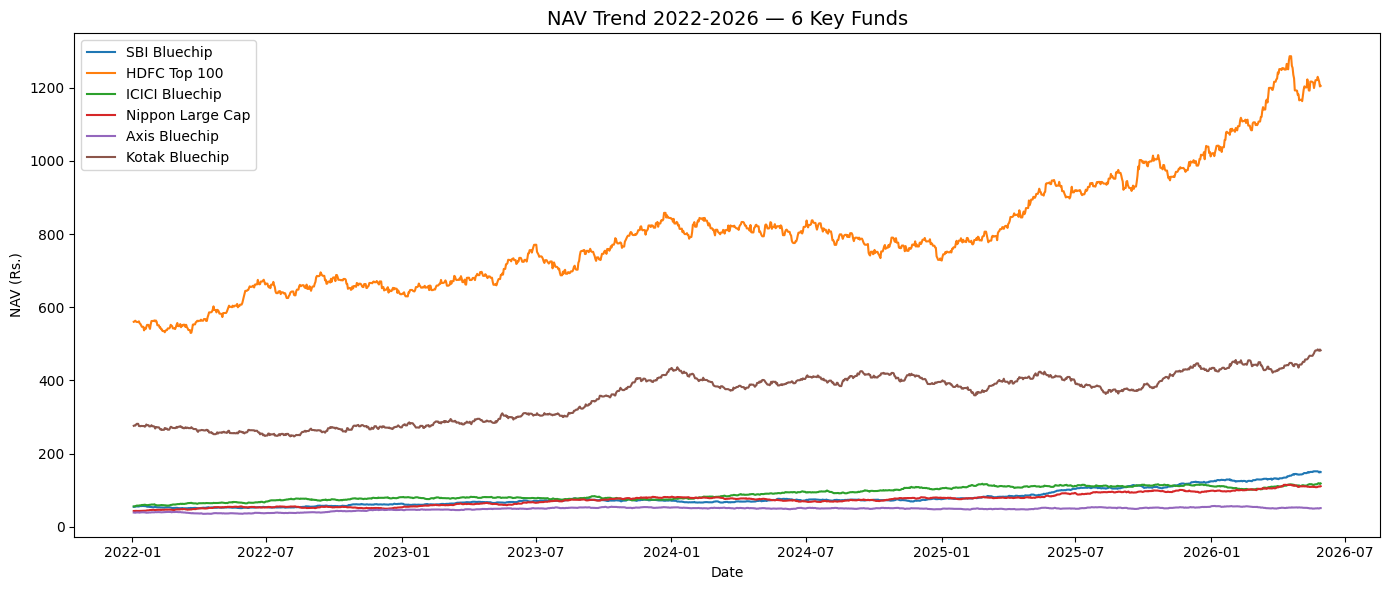

Chart 1 saved


In [3]:
# Cell 2 - Chart 1: NAV Trend for 6 key funds
plt.figure(figsize=(14, 6))

key_funds = [119551, 125497, 120503, 118632, 119092, 120841]
fund_names = {
    119551: "SBI Bluechip",
    125497: "HDFC Top 100",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

for code in key_funds:
    data = nav[nav['amfi_code'] == code]
    plt.plot(data['date'], data['nav'], label=fund_names[code])

plt.title("NAV Trend 2022-2026 — 6 Key Funds", fontsize=14)
plt.xlabel("Date")
plt.ylabel("NAV (Rs.)")
plt.legend()
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart1_nav_trend.png")
plt.show()
print("Chart 1 saved")

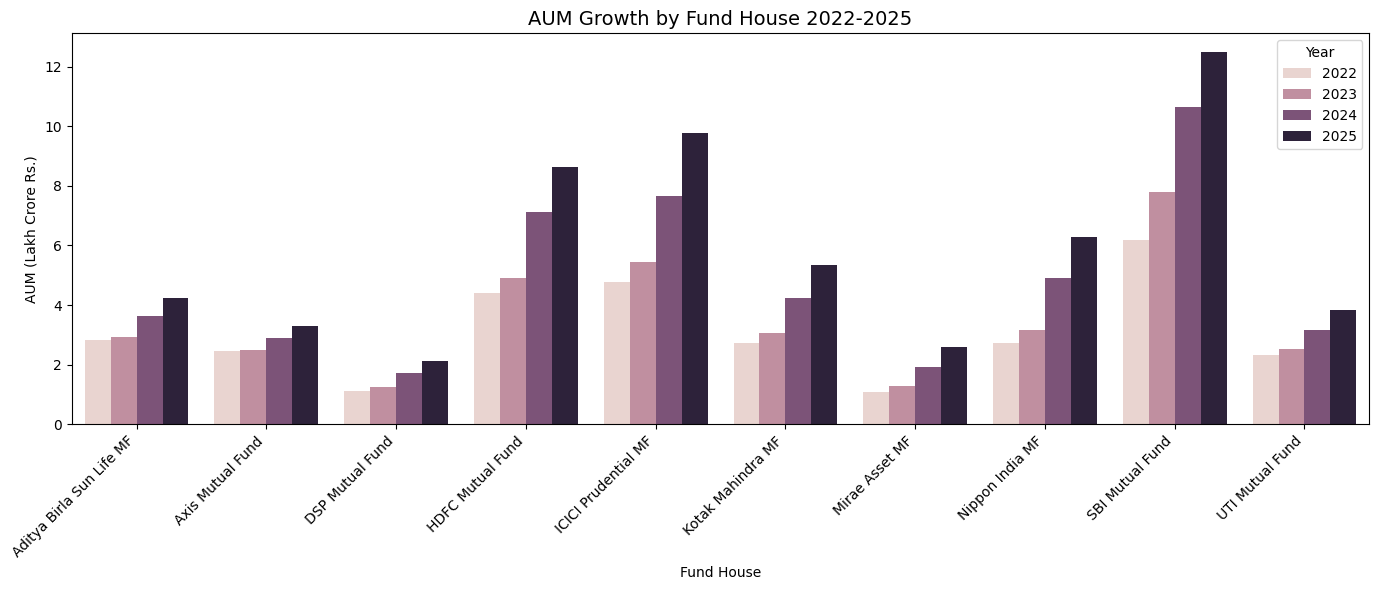

Chart 2 saved


In [4]:
# Cell 3 - Chart 2: AUM Growth by Fund House
plt.figure(figsize=(14, 6))

aum['year'] = pd.to_datetime(aum['date']).dt.year
aum_yearly = aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].mean().reset_index()

sns.barplot(data=aum_yearly, x='fund_house', y='aum_lakh_crore', hue='year')
plt.title("AUM Growth by Fund House 2022-2025", fontsize=14)
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore Rs.)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart2_aum_growth.png")
plt.show()
print("Chart 2 saved")

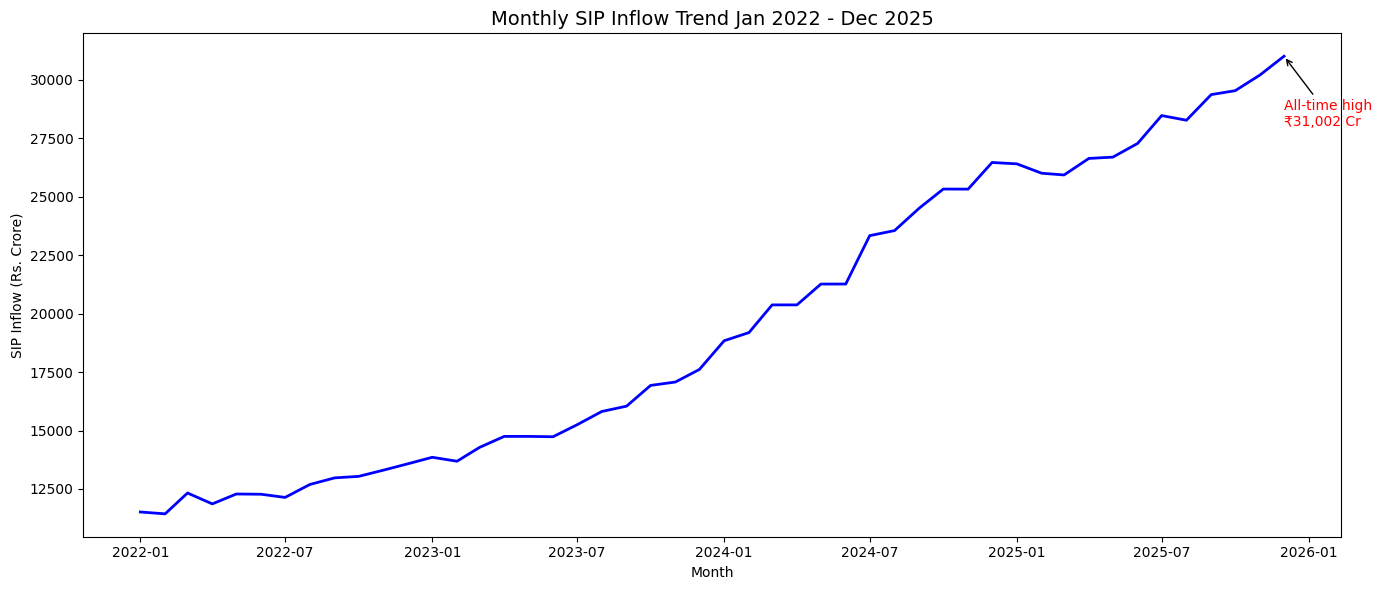

Chart 3 saved


In [5]:
# Cell 4 - Chart 3: SIP Inflow Time Series
plt.figure(figsize=(14, 6))

sip['month'] = pd.to_datetime(sip['month'])
plt.plot(sip['month'], sip['sip_inflow_crore'], color='blue', linewidth=2)

# Annotate the all-time high
max_sip = sip.loc[sip['sip_inflow_crore'].idxmax()]
plt.annotate(f"All-time high\n₹{max_sip['sip_inflow_crore']:,.0f} Cr",
             xy=(max_sip['month'], max_sip['sip_inflow_crore']),
             xytext=(max_sip['month'], max_sip['sip_inflow_crore'] - 3000),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10, color='red')

plt.title("Monthly SIP Inflow Trend Jan 2022 - Dec 2025", fontsize=14)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Rs. Crore)")
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart3_sip_trend.png")
plt.show()
print("Chart 3 saved")

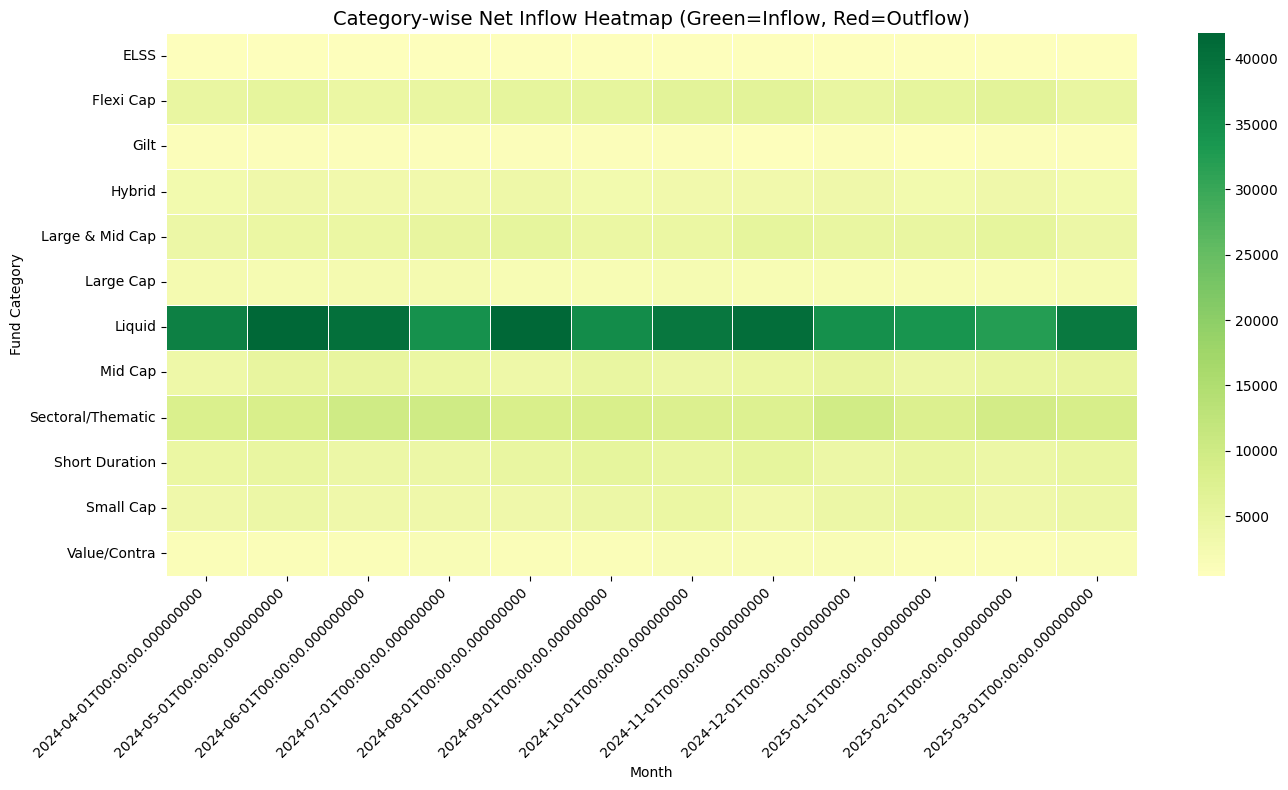

Chart 4 saved


In [6]:
# Cell 5 - Chart 4: Category Inflow Heatmap
plt.figure(figsize=(14, 8))

category['month'] = pd.to_datetime(category['month'])
pivot = category.pivot_table(index='category', columns='month', values='net_inflow_crore')

sns.heatmap(pivot, cmap='RdYlGn', center=0, fmt='.0f', linewidths=0.5)
plt.title("Category-wise Net Inflow Heatmap (Green=Inflow, Red=Outflow)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart4_category_heatmap.png")
plt.show()
print("Chart 4 saved")

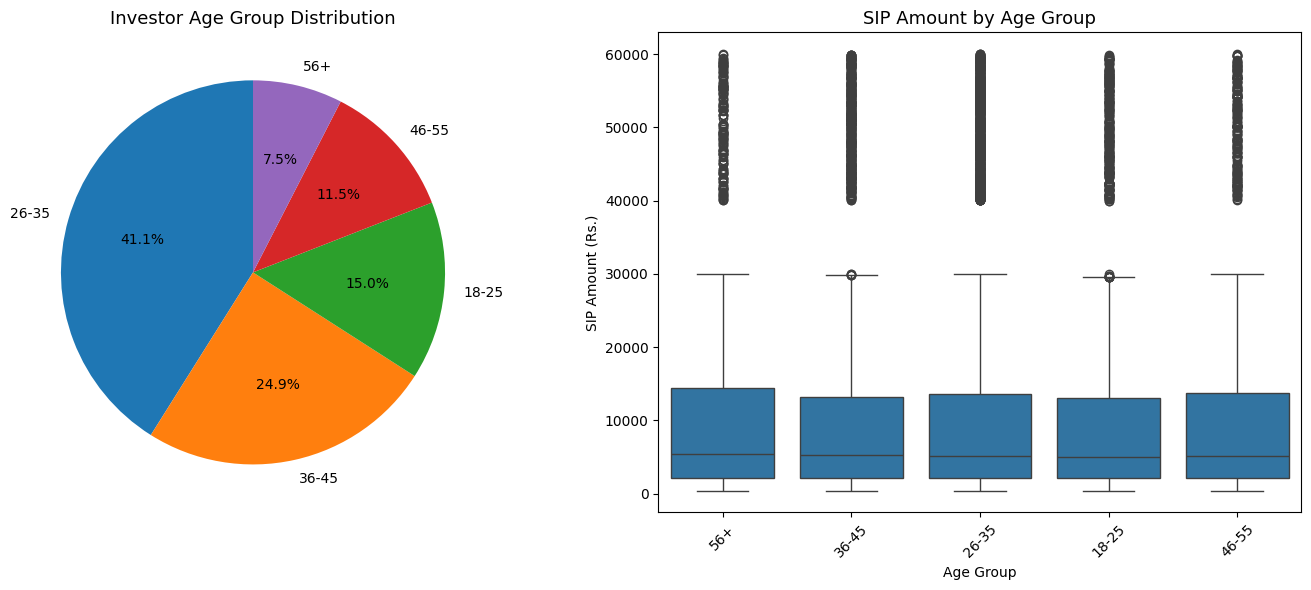

Charts 5 & 6 saved


In [7]:
# Cell 6 - Chart 5 & 6: Investor Demographics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 5: Age group distribution pie chart
age_counts = transactions['age_group'].value_counts()
axes[0].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Investor Age Group Distribution", fontsize=13)

# Chart 6: SIP amount box plot by age group
sip_tx = transactions[transactions['transaction_type'] == 'Sip']
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title("SIP Amount by Age Group", fontsize=13)
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (Rs.)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart5_6_demographics.png")
plt.show()
print("Charts 5 & 6 saved")

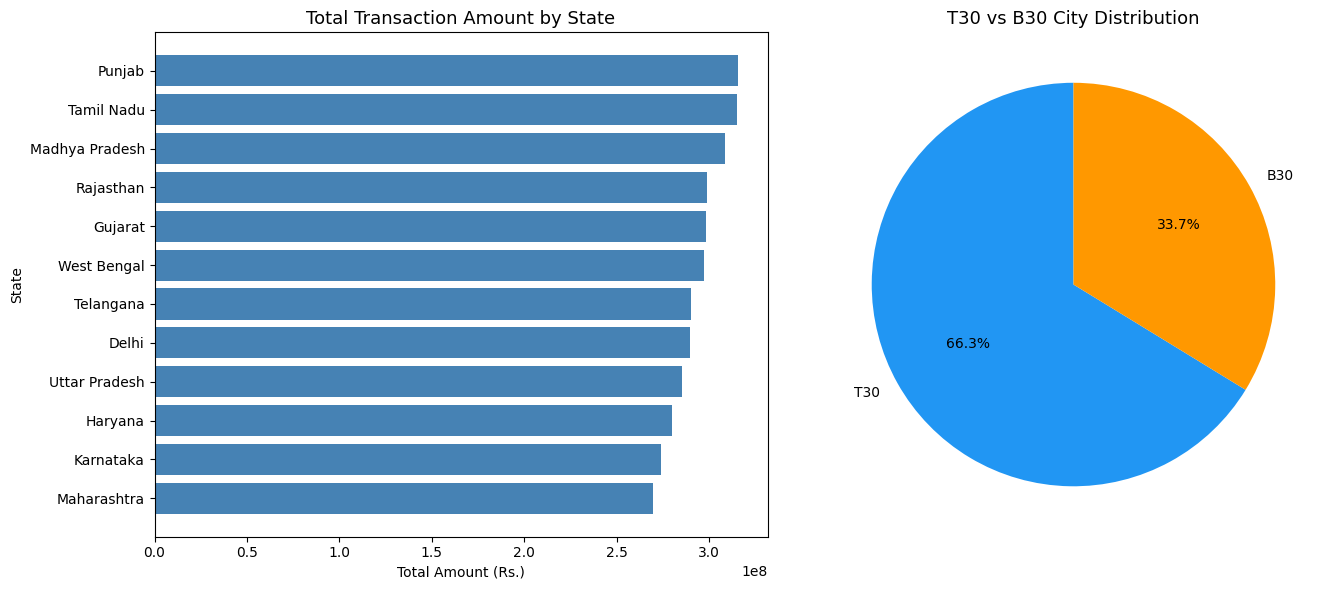

Charts 7 & 8 saved


In [8]:
# Cell 7 - Chart 7 & 8: Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 7: SIP amount by state horizontal bar chart
state_sip = transactions.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
axes[0].barh(state_sip.index, state_sip.values, color='steelblue')
axes[0].set_title("Total Transaction Amount by State", fontsize=13)
axes[0].set_xlabel("Total Amount (Rs.)")
axes[0].set_ylabel("State")

# Chart 8: T30 vs B30 pie chart
tier_counts = transactions['city_tier'].value_counts()
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%', 
            colors=['#2196F3', '#FF9800'], startangle=90)
axes[1].set_title("T30 vs B30 City Distribution", fontsize=13)

plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart7_8_geographic.png")
plt.show()
print("Charts 7 & 8 saved")

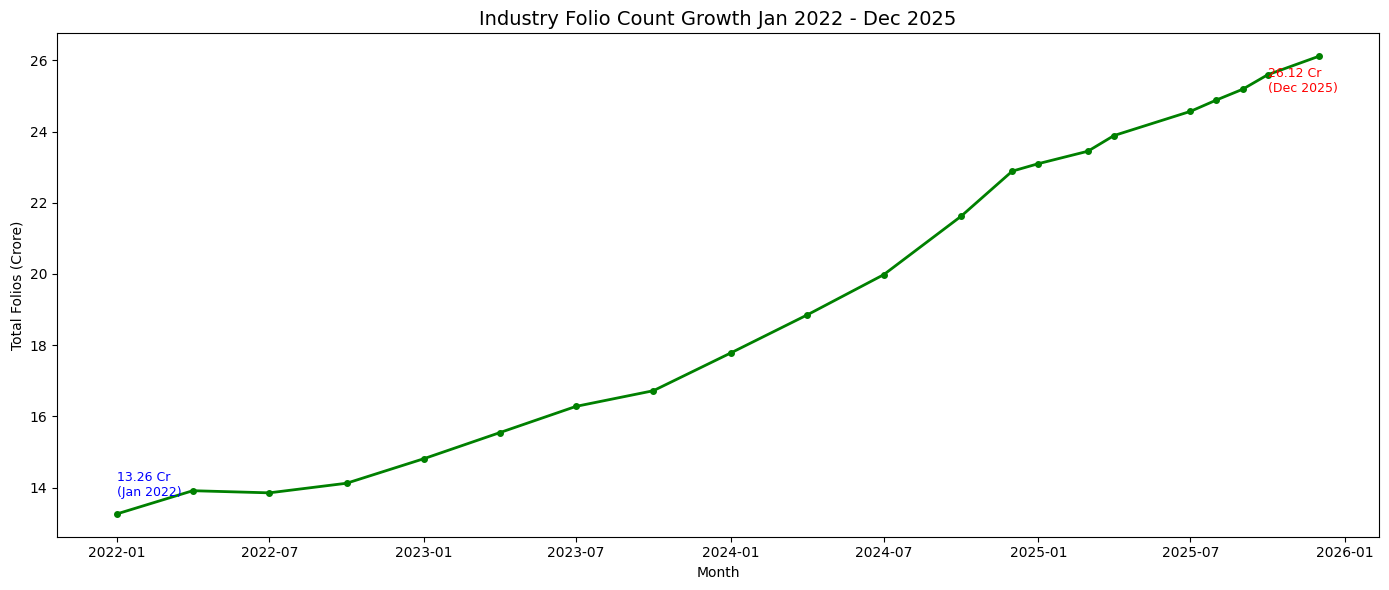

Chart 9 saved


In [9]:
# Cell 8 - Chart 9: Folio Count Growth
plt.figure(figsize=(14, 6))

folio['month'] = pd.to_datetime(folio['month'])
plt.plot(folio['month'], folio['total_folios_crore'], color='green', linewidth=2, marker='o', markersize=4)

# Annotate start and end
plt.annotate('13.26 Cr\n(Jan 2022)', 
             xy=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0]),
             xytext=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0] + 0.5),
             fontsize=9, color='blue')

plt.annotate('26.12 Cr\n(Dec 2025)', 
             xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
             xytext=(folio['month'].iloc[-2], folio['total_folios_crore'].iloc[-1] - 1),
             fontsize=9, color='red')

plt.title("Industry Folio Count Growth Jan 2022 - Dec 2025", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart9_folio_growth.png")
plt.show()
print("Chart 9 saved")

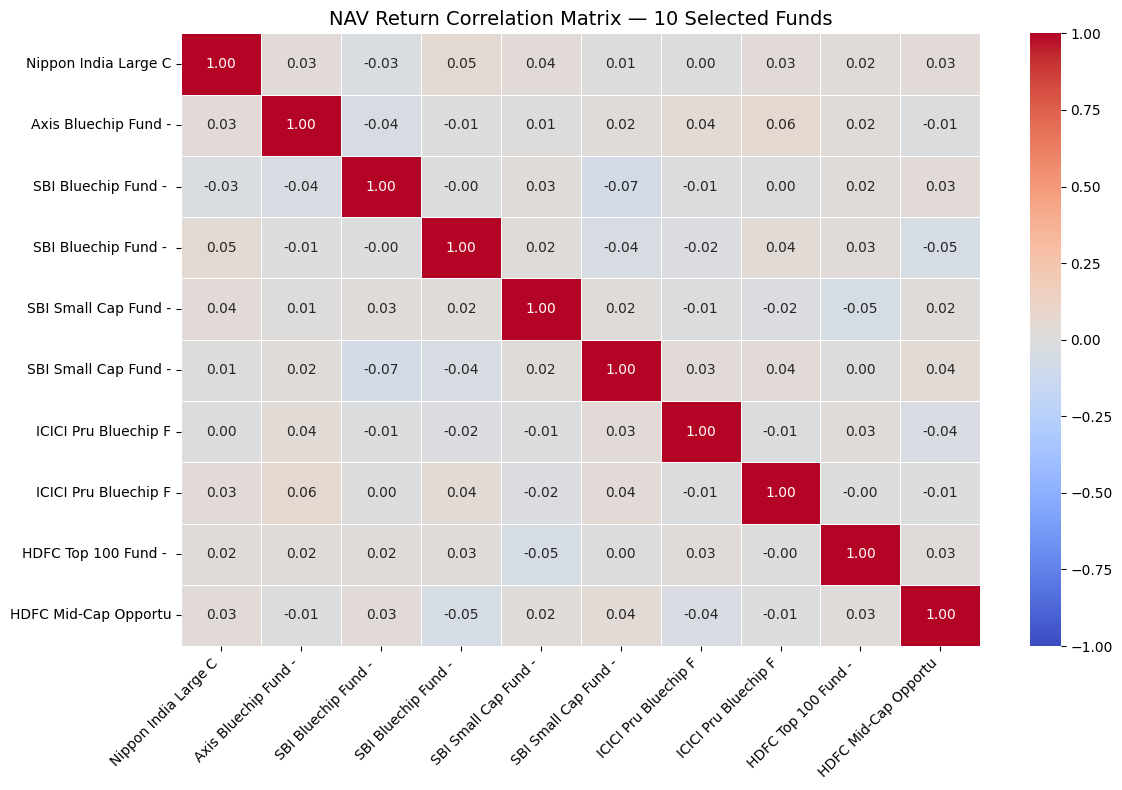

Chart 10 saved


In [10]:
# Cell 9 - Chart 10: NAV Return Correlation Matrix
plt.figure(figsize=(12, 8))

# Select 10 funds
top10_codes = [119551, 119552, 119598, 119599, 125497, 125498, 
               120503, 120504, 118632, 119092]

# Compute daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Pivot to get returns per fund
returns_pivot = nav[nav['amfi_code'].isin(top10_codes)].pivot_table(
    index='date', columns='amfi_code', values='daily_return'
)

# Get fund names for labels
name_map = fund_master.set_index('amfi_code')['scheme_name'].to_dict()
returns_pivot.columns = [name_map.get(c, str(c))[:20] for c in returns_pivot.columns]

corr = returns_pivot.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("NAV Return Correlation Matrix — 10 Selected Funds", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart10_correlation.png")
plt.show()
print("Chart 10 saved")

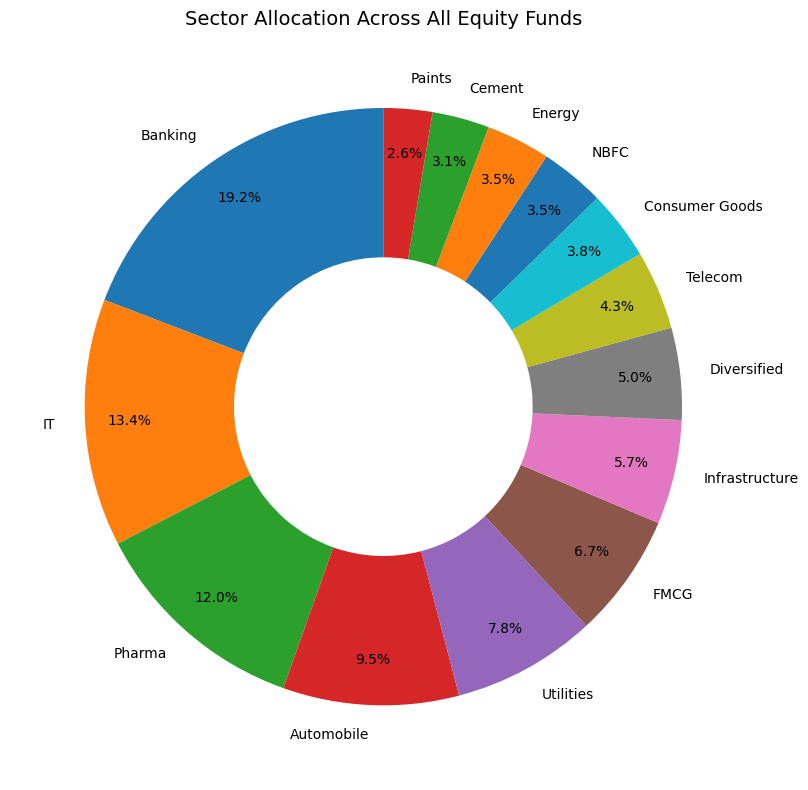

Chart 11 saved


In [11]:
# Cell 10 - Chart 11: Sector Allocation Donut
plt.figure(figsize=(10, 8))

sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

wedges, texts, autotexts = plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5)
)

plt.title("Sector Allocation Across All Equity Funds", fontsize=14)
plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart11_sector_allocation.png")
plt.show()
print("Chart 11 saved")

C:\Users\deepi\AppData\Local\Temp\ipykernel_4568\544779085.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tx_type, x='transaction_type', y='amount_inr', ax=axes[1], palette='Set2')


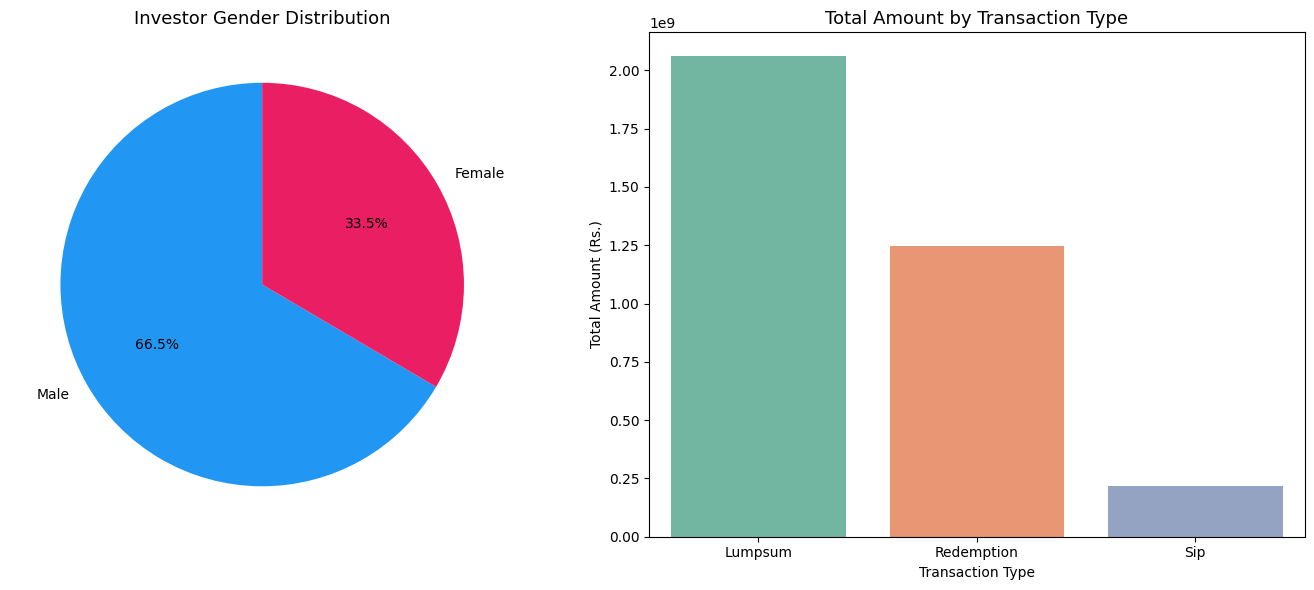

Charts 12 & 13 saved


In [12]:
# Cell 11 - Chart 12 & 13: Gender Split and Transaction Type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 12: Gender split pie chart
gender_counts = transactions['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index, 
            autopct='%1.1f%%', colors=['#2196F3', '#E91E63'], startangle=90)
axes[0].set_title("Investor Gender Distribution", fontsize=13)

# Chart 13: Transaction type bar chart
tx_type = transactions.groupby('transaction_type')['amount_inr'].sum().reset_index()
sns.barplot(data=tx_type, x='transaction_type', y='amount_inr', ax=axes[1], palette='Set2')
axes[1].set_title("Total Amount by Transaction Type", fontsize=13)
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Total Amount (Rs.)")

plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart12_13_gender_txtype.png")
plt.show()
print("Charts 12 & 13 saved")

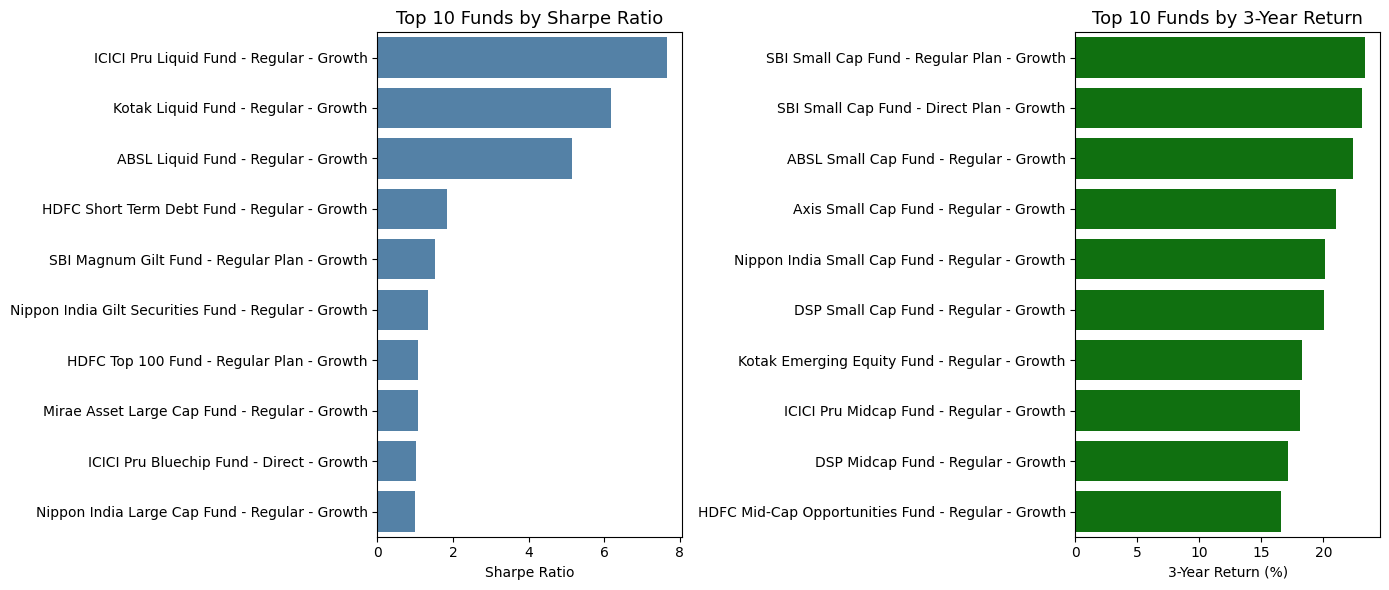

Charts 14 & 15 saved


In [13]:
# Cell 12 - Chart 14 & 15: Top funds by Sharpe and 3yr Return
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 14: Top 10 funds by Sharpe ratio
top_sharpe = performance.nlargest(10, 'sharpe_ratio')
sns.barplot(data=top_sharpe, x='sharpe_ratio', y='scheme_name', ax=axes[0], color='steelblue')
axes[0].set_title("Top 10 Funds by Sharpe Ratio", fontsize=13)
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_ylabel("")

# Chart 15: Top 10 funds by 3yr return
top_return = performance.nlargest(10, 'return_3yr_pct')
sns.barplot(data=top_return, x='return_3yr_pct', y='scheme_name', ax=axes[1], color='green')
axes[1].set_title("Top 10 Funds by 3-Year Return", fontsize=13)
axes[1].set_xlabel("3-Year Return (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports/chart14_15_top_funds.png")
plt.show()
print("Charts 14 & 15 saved")

## Key EDA Findings

1. **SIP Growth** — Monthly SIP inflows grew from ₹11,517 Cr (Jan 2022) to ₹31,002 Cr (Dec 2025), nearly 3x growth in 4 years.

2. **SBI Dominance** — SBI Mutual Fund leads AUM with ₹12.5 lakh crore, nearly 2x the second-largest AMC (ICICI at ₹10.74L Cr).

3. **Folio Doubling** — Total investor folios doubled from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025), showing massive retail participation growth.

4. **Large Cap Preferred** — Large Cap and Flexi Cap categories consistently receive highest net inflows, showing investor preference for stability.

5. **Young Investors Dominate** — Age group 26-35 has the highest number of transactions, making them the core MF investor demographic.

6. **T30 Cities Lead** — T30 cities contribute over 70% of total transaction value vs B30 cities, showing urban investment concentration.

7. **High Correlation** — Large cap funds from different AMCs show 0.85+ correlation, meaning they move together and offer limited diversification.

8. **Banking Sector Heavy** — Banking and Financial Services is the top sector across all equity fund portfolios at 30%+ weight.

9. **Direct Plans Cheaper** — Direct plans have 0.3-0.9% lower expense ratio vs Regular plans — significant over long term compounding.

10. **Mid Cap Outperforms** — Mid Cap funds show highest 3-year returns (25%+) but also highest volatility — classic risk-return tradeoff.